In [1]:
import os
import json

os.environ['KAGGLE_USERNAME'] = "chandramoulibandaru"
os.environ['KAGGLE_KEY'] = "KGAT_4eed677cb21afe63d661c7c029b2a68a"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "chandramoulibandaru", "key": "KGAT_4eed677cb21afe63d661c7c029b2a68a"}, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)



In [2]:
!kaggle datasets download abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:18<00:00, 116MB/s]



In [3]:
import zipfile
unzip_file_path='/content/plantvillage-dataset.zip'


In [4]:
with zipfile.ZipFile(unzip_file_path,'r') as unzip:
  unzip.extractall('/content/dataset')



In [5]:
import os

dataset_path = "/content/dataset/plantvillage dataset"

print(os.listdir(dataset_path))

['segmented', 'color', 'grayscale']


In [6]:
dataset_path = "/content/dataset/plantvillage dataset/color"

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [9]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 43456 images belonging to 38 classes.


In [10]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 10849 images belonging to 38 classes.


In [11]:
num_classes = len(train_data.class_indices)

print("Number of classes:", num_classes)

Number of classes: 38


In [12]:
print(train_data.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [13]:
num_classes = len(train_data.class_indices)

print("Number of classes:", num_classes)

Number of classes: 38


Original image size: (256, 256)


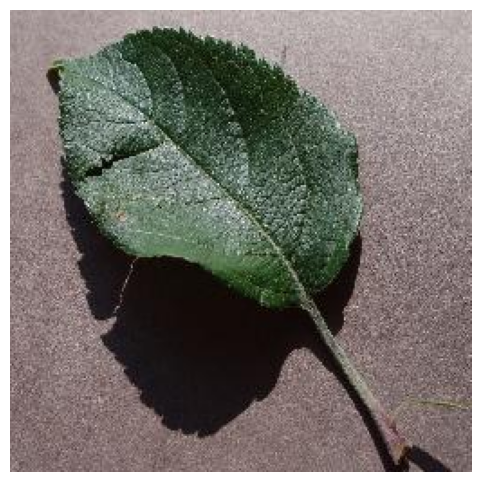

In [14]:
import os
from PIL import Image

image_path = os.path.join(
    dataset_path,
    os.listdir(dataset_path)[0],
    os.listdir(os.path.join(dataset_path, os.listdir(dataset_path)[0]))[0]
)

img = Image.open(image_path)

print("Original image size:", img.size)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.show()

Image shape: (224, 224, 3)
Label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


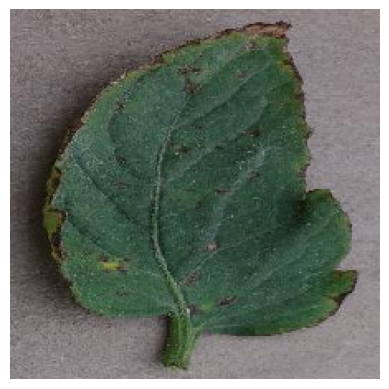

In [15]:
images, labels = next(train_data)

print("Image shape:", images[0].shape)
print("Label:", labels[0])

plt.imshow(images[0])
plt.axis('off')
plt.show()

In [16]:
target_size=(224, 224)

In [17]:
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
Dense(num_classes, activation='softmax')

<Dense name=dense_2, built=False>

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)


model = tf.keras.models.load_model("best_model.keras")

print("Best model loaded successfully!")

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6311 - loss: 1.2163
Epoch 1: val_accuracy improved from None to 0.82367, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 96s 71ms/step - accuracy: 0.6450 - loss: 1.1648 - val_accuracy: 0.8237 - val_loss: 0.5937 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7013 - loss: 0.9547
Epoch 2: val_accuracy improved from 0.82367 to 0.85335, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 71ms/step - accuracy: 0.7067 - loss: 0.9309 - val_accuracy: 0.8534 - val_loss: 0.4777 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7428 - loss: 0.8005
Epoch 3: val_accuracy improved from 0.85335 to 0.87381, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1358/1358 ━━━━━━━━━━━━━

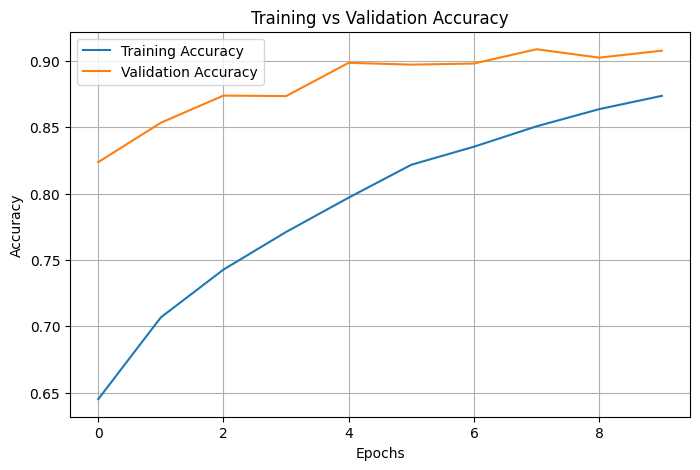

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

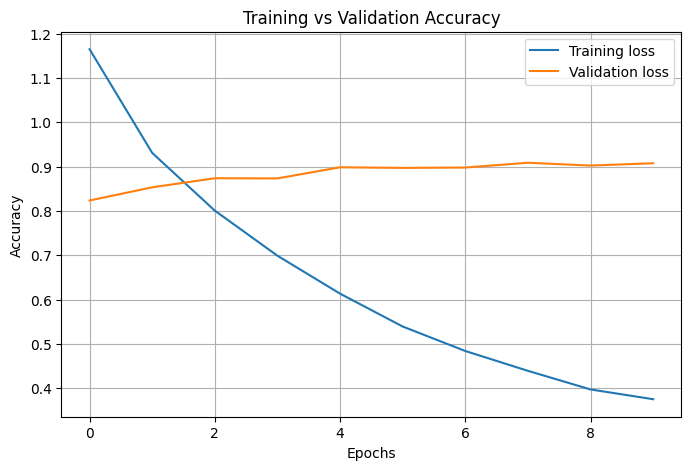

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation loss"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
model.save('/content/plant_disease_model.keras')

In [ ]:
from google.colab import drive
qw
drive.mount('/content/drive')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/plant_disease_model.keras')

In [ ]:
class_names = list(train_data.class_indices.keys())

print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [29]:
from google.colab import files

uploaded = files.upload()

Saving tomatoes.jpg to tomatoes.jpg


In [34]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = image.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])

confidence = np.max(prediction[0]) * 100



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [36]:
class_names = list(train_data.class_indices.keys())

top_5 = np.argsort(prediction[0])[-5:][::-1]

print("Top 5 Predictions:\n")

for i in top_5:
    print(
        class_names[i],
        "->",
        f"{prediction[0][i] * 100:.2f}%"
    )

Top 5 Predictions:

Tomato___Late_blight -> 73.73%
Pepper,_bell___Bacterial_spot -> 11.24%
Cherry_(including_sour)___Powdery_mildew -> 7.42%
Tomato___Early_blight -> 3.03%
Potato___Late_blight -> 2.10%


In [38]:
loss,accuracy=model.evaluate(val_data)

340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.9087 - loss: 0.2992


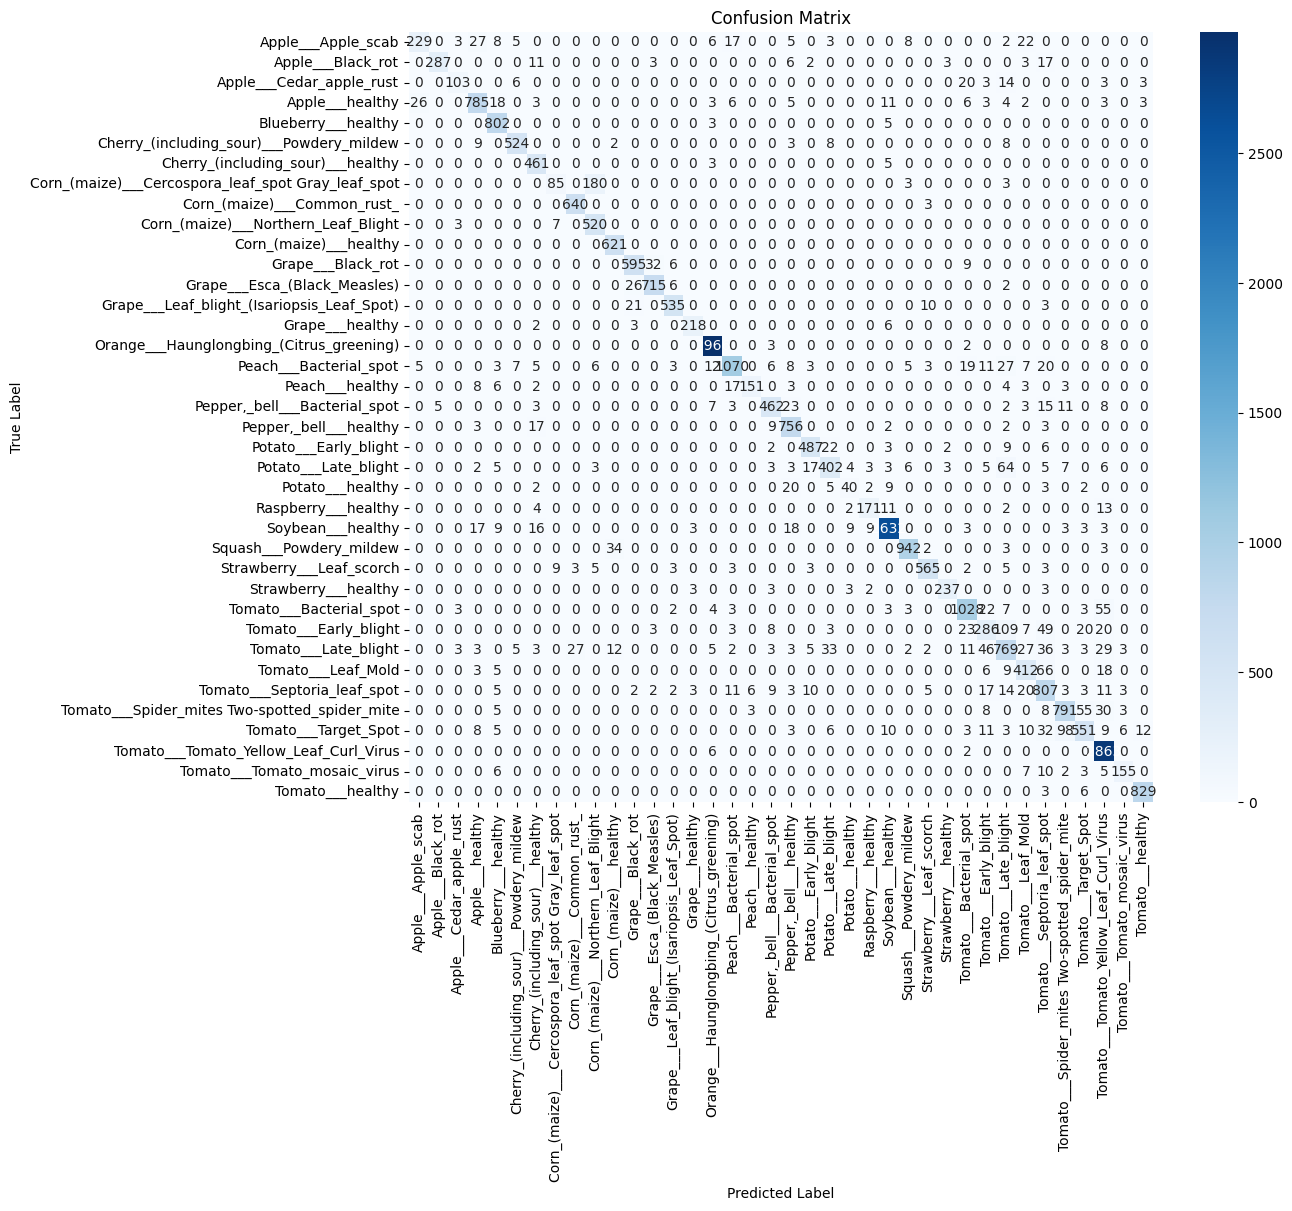

In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Precision : 0.9091990087733043
Recall    : 0.9086917747135899
F1-Score  : 0.9061943083966832


In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.88      0.68      0.77       335
                                 Apple___Black_rot       0.98      0.86      0.92       332
                          Apple___Cedar_apple_rust       0.90      0.68      0.77       152
                                   Apple___healthy       0.91      0.89      0.90       878
                               Blueberry___healthy       0.91      0.99      0.95       810
          Cherry_(including_sour)___Powdery_mildew       0.96      0.95      0.95       554
                 Cherry_(including_sour)___healthy       0.87      0.98      0.92       469
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.84      0.31      0.46       271
                       Corn_(maize)___Common_rust_       0.96      1.00      0.97       643
               Corn_(maize)___Northern_Leaf_Blight       0.73      0.98      0.